# Deep Learning - LSTM ile Günlük Suç Sayısı Tahmini

LSTM, zaman serileri gibi sıralı verilerde geçmiş bilgiyi hatırlayabilen bir yapay sinir ağı türüdür. Son 30 günün suç sayısına bakarak ertesi günü tahmin edeceğiz.

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
df=pd.read_csv('la_crime.csv',usecols=['DATE OCC'])
df['tarih']=pd.to_datetime(df['DATE OCC'],format='mixed',errors='coerce').dt.normalize()
gunluk=df.groupby('tarih').size()
gunluk=gunluk.asfreq('D',fill_value=0)
gunluk=gunluk.iloc[:-7]   # son günlerin kayıtları eksik olabilir

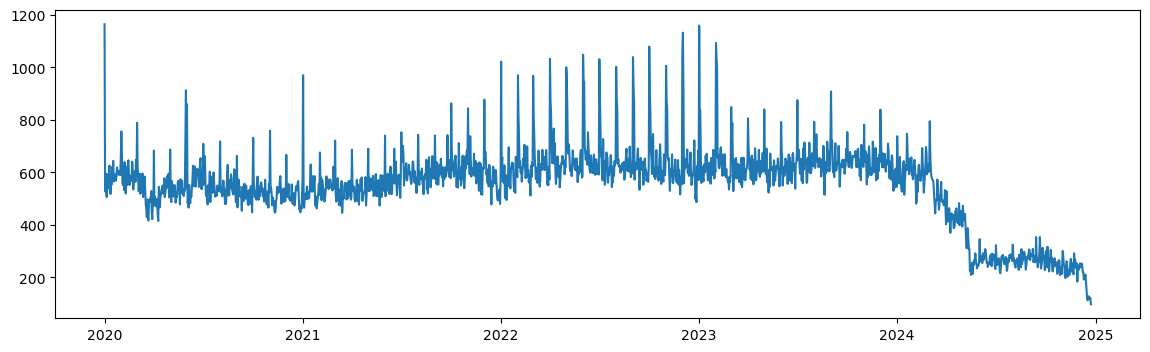

In [4]:
plt.figure(figsize=(14,4))
plt.plot(gunluk)
plt.show()

Sinir ağları 0-1 arası ölçeklenmiş veriyle daha iyi öğrenir.

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
s=scaler.fit_transform(gunluk.values.reshape(-1,1))

In [6]:
pencere=30
X=np.array([s[i-pencere:i,0] for i in range(pencere,len(s))]).reshape(-1,pencere,1)
y=np.array([s[i,0] for i in range(pencere,len(s))])
X.shape

(1789, 30, 1)

Zaman serisinde son 60 gün test olarak ayrılır.

In [7]:
test_sayisi=60
x_train,x_test=X[:-test_sayisi],X[-test_sayisi:]
y_train,y_test=y[:-test_sayisi],y[-test_sayisi:]

In [8]:
model=keras.Sequential([
    layers.Input(shape=(pencere,1)),
    layers.LSTM(32),
    layers.Dense(16,activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
gecmis=model.fit(x_train,y_train,validation_split=.1,epochs=15,batch_size=32,verbose=1)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 0.0212 - val_loss: 0.0086
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0052 - val_loss: 0.0083
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0051 - val_loss: 0.0068
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0051 - val_loss: 0.0060
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0051 - val_loss: 0.0054
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0050 - val_loss: 0.0053
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0050 - val_loss: 0.0040
Epoch 9/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 10/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0049 - val_loss: 0.0039
Epoch 11/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0049 - val_loss: 0.0038
Epoch 12/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.

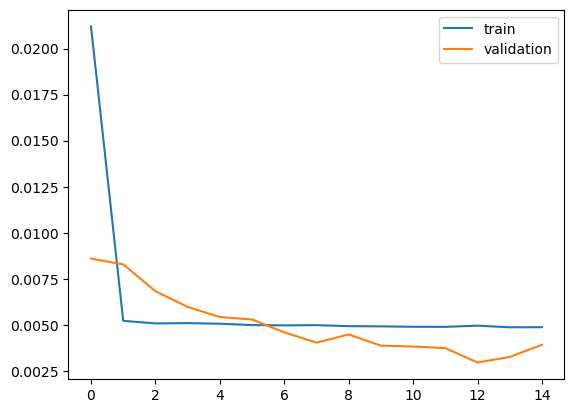

In [10]:
plt.plot(gecmis.history['loss'],label='train')
plt.plot(gecmis.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
tahmin=scaler.inverse_transform(model.predict(x_test)).flatten()
gercek=scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
print('R2:',r2_score(gercek,tahmin))
print('RMSE:',np.sqrt(mean_squared_error(gercek,tahmin)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
R2: -1.6867360614946394
RMSE: 77.46788226543862


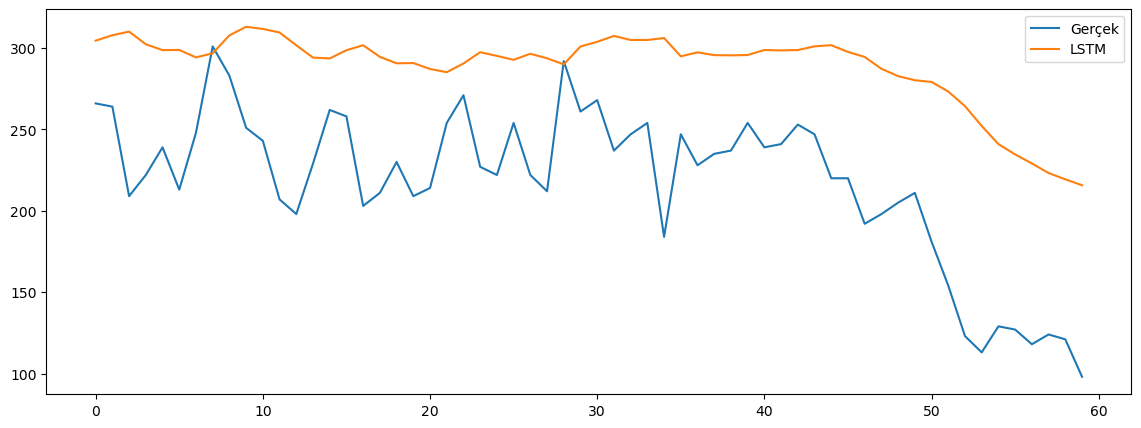

In [12]:
plt.figure(figsize=(14,5))
plt.plot(gercek,label='Gerçek')
plt.plot(tahmin,label='LSTM')
plt.legend()
plt.show()

In [13]:
import pickle
model.save('suc_lstm_model.keras')
pickle.dump(scaler,open('lstm_scaler.pkl','wb'))
son={'son_degerler':gunluk.iloc[-pencere:].tolist(),'son_tarih':gunluk.index[-1]}
pickle.dump(son,open('lstm_son.pkl','wb'))